In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

- k-meansクラスタリング

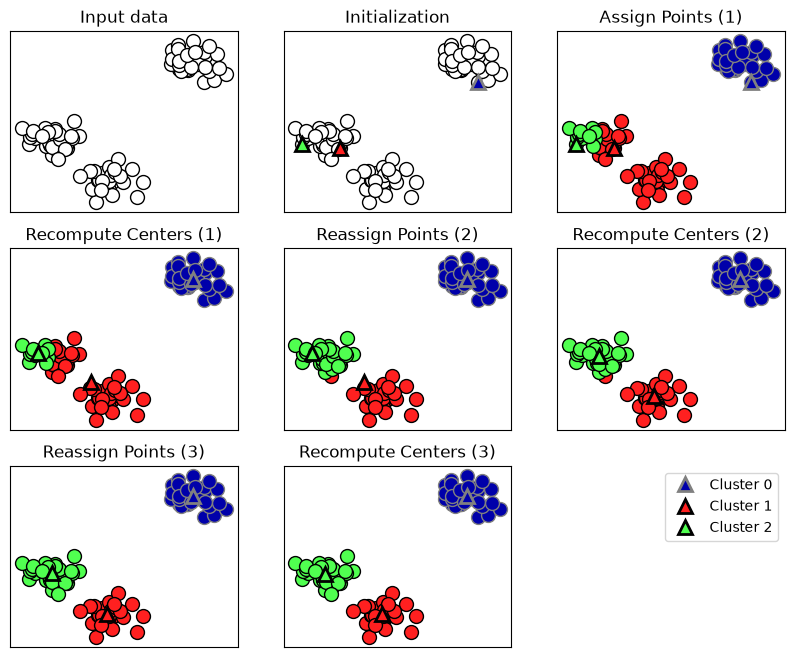

In [2]:
mglearn.plots.plot_kmeans_algorithm()

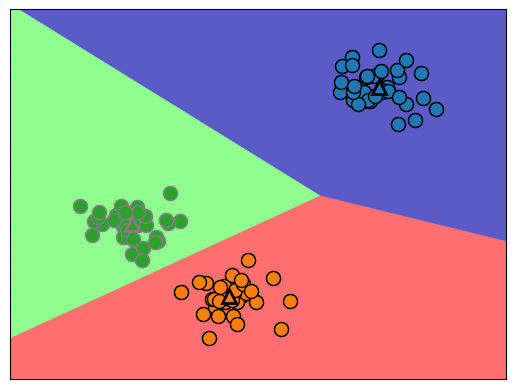

In [4]:
#クラスタセンタの境界を示す
mglearn.plots.plot_kmeans_boundaries()
plt.show()

In [10]:
#k-meansのクラスタリングを行う
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

x,y = make_blobs(random_state=1)

kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
print("Cluster memberships:\n{}".format(kmeans.labels_))

Cluster memberships:
[0 2 2 2 1 1 1 2 0 0 2 2 1 0 1 1 1 0 2 2 1 2 1 0 2 1 1 0 0 1 0 0 1 0 2 1 2
 2 2 1 1 2 0 2 2 1 0 0 0 0 2 1 1 1 0 1 2 2 0 0 2 1 1 2 2 1 0 1 0 2 2 2 1 0
 0 2 1 1 0 2 0 2 2 1 0 0 0 0 2 0 1 0 0 2 2 1 1 0 1 0]


In [ ]:
#訓練セットに対してpredictを行うと、kmeans.labels_と同じ結果が得られる
print(kmeans.predict(x))

[0 2 2 2 1 1 1 2 0 0 2 2 1 0 1 1 1 0 2 2 1 2 1 0 2 1 1 0 0 1 0 0 1 0 2 1 2
 2 2 1 1 2 0 2 2 1 0 0 0 0 2 1 1 1 0 1 2 2 0 0 2 1 1 2 2 1 0 1 0 2 2 2 1 0
 0 2 1 1 0 2 0 2 2 1 0 0 0 0 2 0 1 0 0 2 2 1 1 0 1 0]


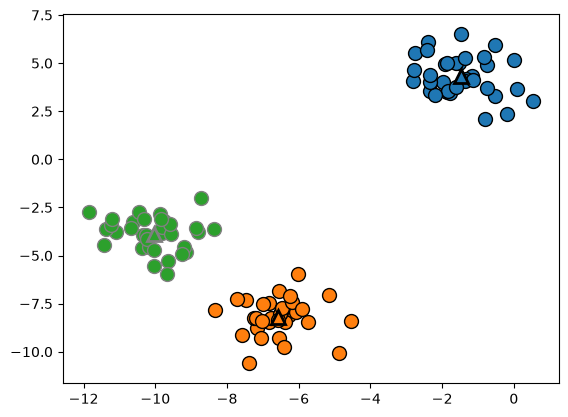

In [13]:
mglearn.discrete_scatter(x[:, 0], x[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
    markers='^', markeredgewidth=2)
plt.show()

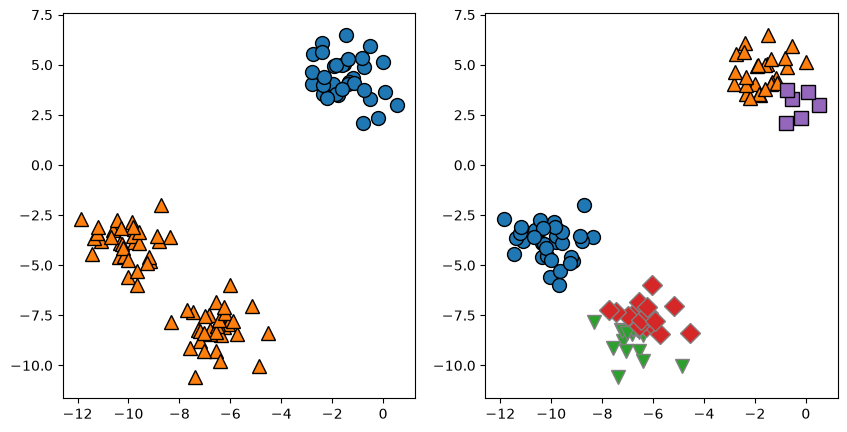

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

kmeans = KMeans(n_clusters=2)
kmeans.fit(x)
assignments = kmeans.labels_
mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments, ax=axes[0])

kmeans = KMeans(n_clusters=5)
kmeans.fit(x)
assignments = kmeans.labels_
mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments, ax=axes[1])

plt.show()

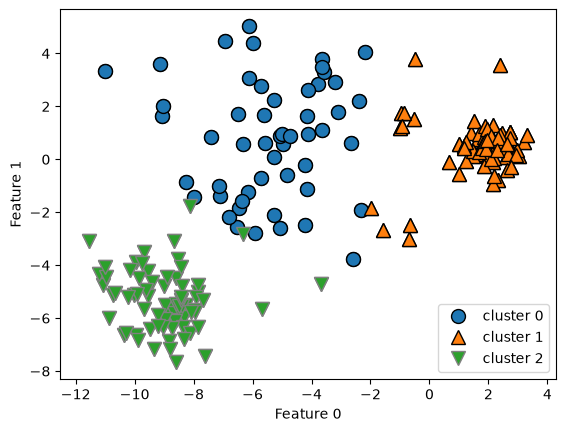

In [ ]:
#k-meansでは比較的単純な形しか表現できない
#K-meansは「丸っぽく、同程度の大きさ・密度のクラスタ」には強いが、
# クラスタの大きさや広がりが大きく異なるデータでは、直感的なグループ分けとズレることがある。

x_varied,y_varied = make_blobs(n_samples=200, 
                               cluster_std=[1.0,2.5,0.5], 
                               random_state=170
                               )

y_pred = KMeans(n_clusters=3, random_state=0).fit_predict(x_varied)
mglearn.discrete_scatter(x_varied[:, 0], x_varied[:, 1], y_pred)
plt.legend(["cluster 0", "cluster 1", "cluster 2"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

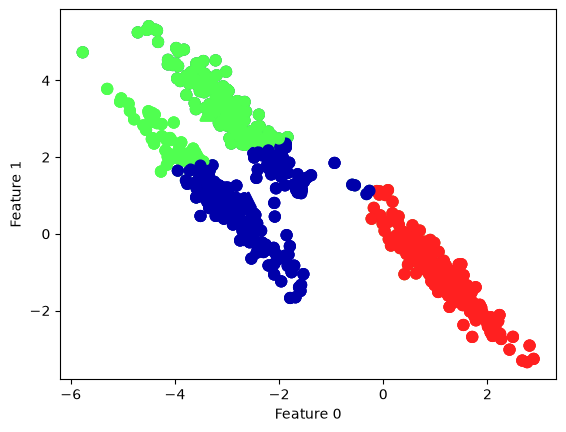

In [ ]:
#k-meansは最も近いクラスタセンタへの距離しか考慮しないので、このようなデータを取り扱うことはできない
#k-meansは丸くないクラスタを識別できない

#ランダムにクラスタデータを生成
x,y = make_blobs(n_samples=600,
                 random_state=170
)
rng = np.random.RandomState(74)

#回転・拡大縮小・せん断などが混ざった線形変換をする
taransformation = rng.normal(size=(2,2))
x = np.dot(x, taransformation)

#データポイントを３つにクラスタリング
kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
y_pred = kmeans.predict(x)

#クラスタ割り当てとクラスタセンタをプロット
plt.scatter(x[:, 0], x[:, 1], c=y_pred, s=60, cmap=mglearn.cm3)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='^', c=[0, 1, 2], s=100, linewidth=2, cmap=mglearn.cm3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

